### Importing Required Libraries

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

### Reading and Understanding Data

In [9]:
!pip install openpyxl

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)



[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
df = pd.read_excel('university.xlsx')
df.head()

,Univ,State,SAT,Top10,Accept,SFRatio,Expenses,GradRate
0,Brown,RI,1310,89,22,13,22704,94
1,CalTech,CA,1415,100,25,6,63575,81
2,CMU,PA,1260,62,59,9,25026,72
3,Columbia,NY,1310,76,24,12,31510,88
4,Cornell,NY,1280,83,33,13,21864,90


In [15]:
df = df.drop(columns = ['Univ','State'])


In [16]:
df.head()

,SAT,Top10,Accept,SFRatio,Expenses,GradRate
0,1310,89,22,13,22704,94
1,1415,100,25,6,63575,81
2,1260,62,59,9,25026,72
3,1310,76,24,12,31510,88
4,1280,83,33,13,21864,90


### Scaling

In [19]:
from sklearn.preprocessing import StandardScaler

for col in df.columns:
    ss = StandardScaler()
    df[col] = ss.fit_transform(df[[col]])

In [20]:
df.head()

,SAT,Top10,Accept,SFRatio,Expenses,GradRate
0,0.410284,0.657519,-0.889867,0.070260,-0.331413,0.820303
1,1.399259,1.235212,-0.734657,-1.686251,2.560381,-0.644524
2,-0.060657,-0.760454,1.024382,-0.933460,-0.167121,-1.658634
3,0.410284,-0.025208,-0.786394,-0.180670,0.291649,0.144229
4,0.127719,0.342414,-0.320766,0.070260,-0.390846,0.369587


In [23]:
# Let's try to findout best k value
from sklearn.cluster import KMeans
wcss = []
for k in range(1,10):
    km = KMeans(n_clusters = k)
    km.fit(df)
    wcss.append(km.inertia_)

In [24]:
wcss

[150.0,
 64.1452839501027,
 44.666152784702376,
 34.79612750585774,
 30.046185767558804,
 25.085335037696176,
 20.343571123316796,
 16.179913894092927,
 13.623980850972172]

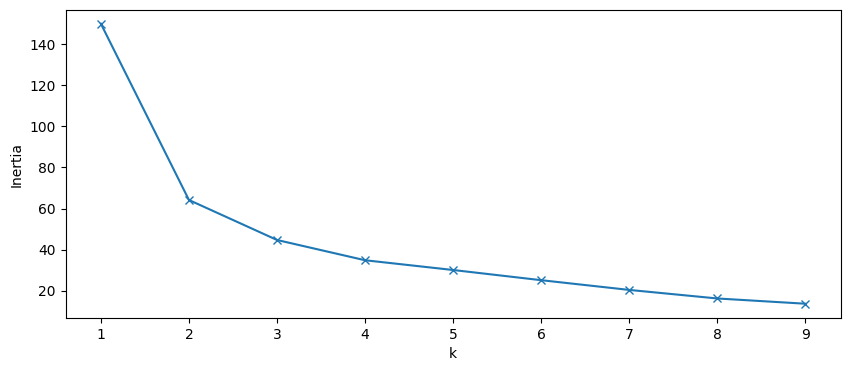

In [27]:
plt.figure(figsize=[10,4])
plt.plot(range(1,10),wcss,marker = 'x')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.show()

### Final Model

In [28]:
kmf = KMeans(n_clusters=3,random_state=0)
labels = kmf.fit_predict(df)

In [29]:
df['labels'] = labels

In [30]:
df.head()

,SAT,Top10,Accept,SFRatio,Expenses,GradRate,labels
0,0.410284,0.657519,-0.889867,0.070260,-0.331413,0.820303,1
1,1.399259,1.235212,-0.734657,-1.686251,2.560381,-0.644524,2
2,-0.060657,-0.760454,1.024382,-0.933460,-0.167121,-1.658634,1
3,0.410284,-0.025208,-0.786394,-0.180670,0.291649,0.144229,1
4,0.127719,0.342414,-0.320766,0.070260,-0.390846,0.369587,1


In [32]:
new_df = pd.read_excel('university.xlsx')
new_df['labels'] = labels
new_df.head()

,Univ,State,SAT,Top10,Accept,SFRatio,Expenses,GradRate,labels
0,Brown,RI,1310,89,22,13,22704,94,1
1,CalTech,CA,1415,100,25,6,63575,81,2
2,CMU,PA,1260,62,59,9,25026,72,1
3,Columbia,NY,1310,76,24,12,31510,88,1
4,Cornell,NY,1280,83,33,13,21864,90,1


In [33]:
# best University
new_df[new_df['labels'] == 2]['Univ']

1         CalTech
9    JohnsHopkins
Name: Univ, dtype: object

In [34]:
# good University
new_df[new_df['labels'] == 1]['Univ']

0            Brown
2              CMU
3         Columbia
4          Cornell
5        Dartmouth
6             Duke
7       Georgetown
8          Harvard
10             MIT
11    Northwestern
12       NotreDame
14       Princeton
16        Stanford
18      UCBerkeley
19        UChicago
21           UPenn
22             UVA
24            Yale
Name: Univ, dtype: object

In [36]:
# worst University
new_df[new_df['labels'] == 0]['Univ']

13     PennState
15        Purdue
17      TexasA&M
20     UMichigan
23    UWisconsin
Name: Univ, dtype: object

### PCA

In [37]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3,random_state=1)

components = pca.fit_transform(df)

In [38]:
components.shape

(25, 3)

In [45]:
pc1 = components[:,0]
pc2 = components[:,1]
pc3 = components[:,2]

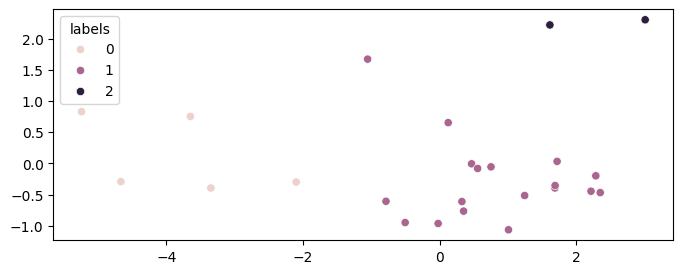

In [52]:
plt.figure(figsize=[8,3])
sns.scatterplot(data = df, x = pc1 , y = pc2 , hue = df['labels'])
plt.show()

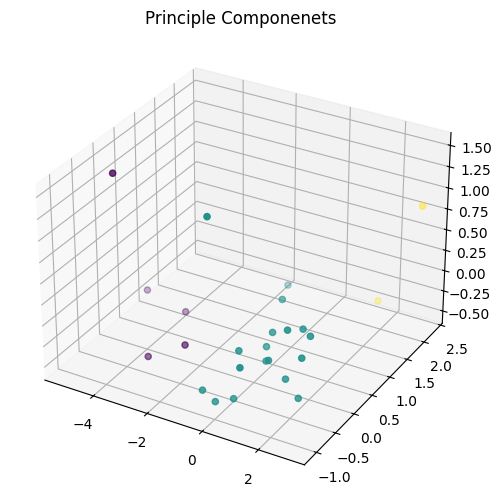

In [58]:
fig = plt.figure(figsize=[8,6])
ax = plt.axes(projection = '3d')
ax.set_title("Principle Componenets")
ax.scatter(pc1,pc2,pc3,c = df['labels'])
plt.show()